In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv('Cleaned_Car_Price_Data.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        724 non-null    object
 1   company     724 non-null    object
 2   year        724 non-null    int64 
 3   Price       724 non-null    int64 
 4   kms_driven  724 non-null    int64 
 5   fuel_type   724 non-null    object
dtypes: int64(3), object(3)
memory usage: 34.1+ KB


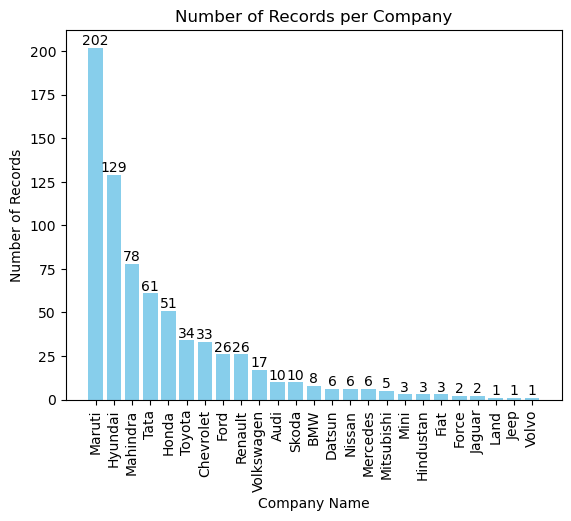

In [17]:
#Lets find number of vehicles by company
company_counts  = df['company'].value_counts()
# company_counts.plot(kind='bar')
fig, ax = plt.subplots()
# Add labels and title
plt.xlabel('Company Name')
plt.ylabel('Number of Records')
plt.title('Number of Records per Company')

# Plot bar chart
bars = ax.bar(company_counts.index, company_counts.values, color='skyblue')
ax.bar_label(bars)
plt.xticks(rotation=90)

# Display chart
plt.show()

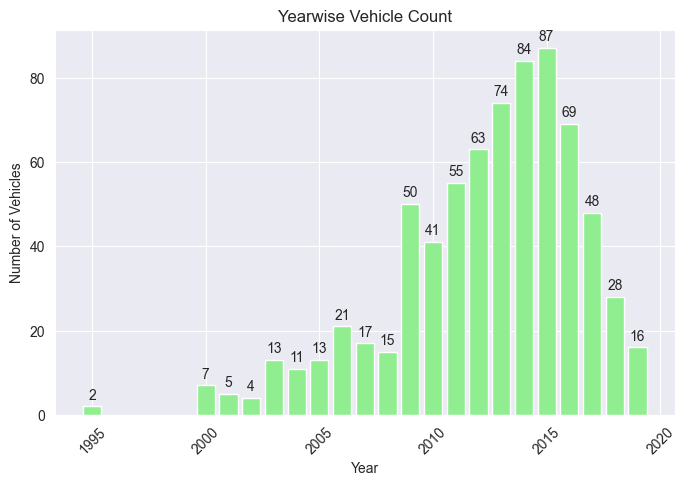

In [34]:
# Count number of vehicles per year
year_counts = df['year'].value_counts().sort_index()  # sort_index() ensures ascending year order
# Create figure
fig, ax = plt.subplots(figsize=(8, 5))
# Plot bar chart

bars = ax.bar(year_counts.index, year_counts.values, color='lightgreen')
# Add value labels on bars
ax.bar_label(bars, padding=3)
# Add labels and title
plt.xlabel('Year')
plt.ylabel('Number of Vehicles')
plt.title('Yearwise Vehicle Count')
# Improve readability
plt.xticks(rotation=45)
plt.show()

fuel_type
Petrol    390
Diesel    332
LPG         2
Name: count, dtype: int64


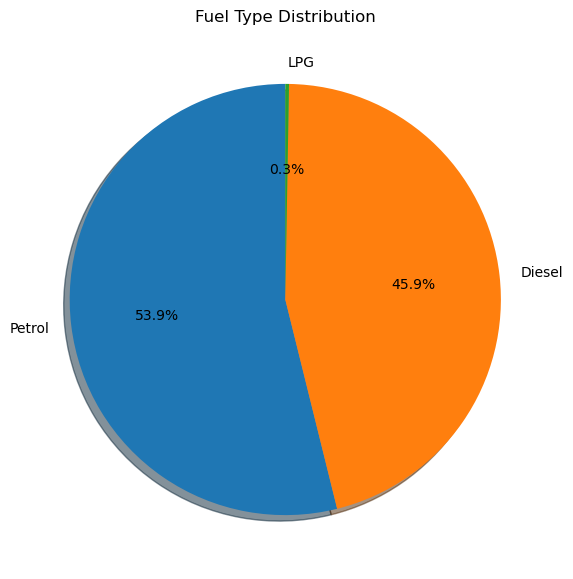

In [19]:
# Count vehicles by fuel type
fuel_counts = df['fuel_type'].value_counts()
print(fuel_counts)
# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(
    fuel_counts.values, 
    labels=fuel_counts.index,
    autopct='%1.1f%%',         # show percentage with 1 decimal place
    startangle=90,             # rotate for better view
    shadow=True,               # adds 3D look
    # explode=[0.05]*len(fuel_counts),  # separate each slice slightly
    # wedgeprops={'edgecolor': 'white'}
)
# Add title
plt.title('Fuel Type Distribution')
# Display chart
plt.show()

In [21]:
table = pd.crosstab(df['company'], df['fuel_type'], margins=True, margins_name='Total')
print(table)

fuel_type   Diesel  LPG  Petrol  Total
company                               
Audi             7    0       3     10
BMW              5    0       3      8
Chevrolet       20    0      13     33
Datsun           0    0       6      6
Fiat             1    0       2      3
Force            2    0       0      2
Ford            16    0      10     26
Hindustan        2    0       1      3
Honda           12    0      39     51
Hyundai         25    0     104    129
Jaguar           1    0       1      2
Jeep             1    0       0      1
Land             1    0       0      1
Mahindra        75    0       3     78
Maruti          55    2     145    202
Mercedes         2    0       4      6
Mini             0    0       3      3
Mitsubishi       3    0       2      5
Nissan           3    0       3      6
Renault         18    0       8     26
Skoda            7    0       3     10
Tata            46    0      15     61
Toyota          18    0      16     34
Volkswagen      11    0  

In [25]:
counts = df.groupby(['company', 'fuel_type']).size().reset_index(name='count')
print(counts)

       company fuel_type  count
0         Audi    Diesel      7
1         Audi    Petrol      3
2          BMW    Diesel      5
3          BMW    Petrol      3
4    Chevrolet    Diesel     20
5    Chevrolet    Petrol     13
6       Datsun    Petrol      6
7         Fiat    Diesel      1
8         Fiat    Petrol      2
9        Force    Diesel      2
10        Ford    Diesel     16
11        Ford    Petrol     10
12   Hindustan    Diesel      2
13   Hindustan    Petrol      1
14       Honda    Diesel     12
15       Honda    Petrol     39
16     Hyundai    Diesel     25
17     Hyundai    Petrol    104
18      Jaguar    Diesel      1
19      Jaguar    Petrol      1
20        Jeep    Diesel      1
21        Land    Diesel      1
22    Mahindra    Diesel     75
23    Mahindra    Petrol      3
24      Maruti    Diesel     55
25      Maruti       LPG      2
26      Maruti    Petrol    145
27    Mercedes    Diesel      2
28    Mercedes    Petrol      4
29        Mini    Petrol      3
30  Mits

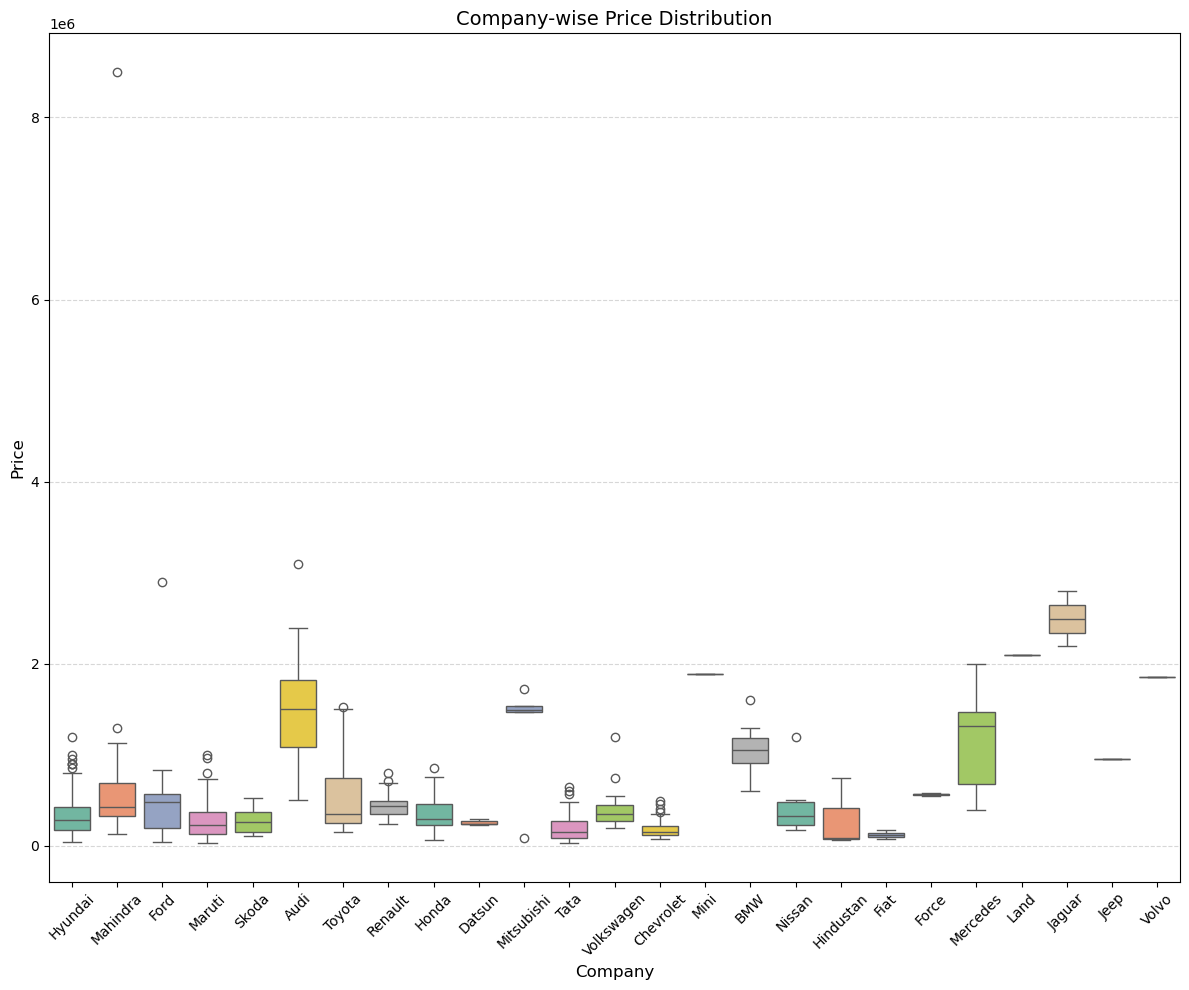

In [27]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df, x='company', y='Price', palette='Set2')

plt.title('Company-wise Price Distribution', fontsize=14)
plt.xlabel('Company', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [29]:
# Define bins (price ranges)
bins = [0, 500000, 1000000, 1500000, 2000000, 3000000, 5000000, 10000000]

# Define corresponding group names (labels)
labels = [
    '0 - 5 Lakh',
    '5 - 10 Lakh',
    '10 - 15 Lakh',
    '15 - 20 Lakh',
    '20 - 30 Lakh',
    '30 - 50 Lakh',
    '50 Lakh - 1 Cr'
]
# Add a new column 'group' in your DataFrame
df['group'] = pd.cut(df['Price'], bins=bins, labels=labels, right=True)

In [31]:
pd.crosstab(df['group'], df['company'])

company,Audi,BMW,Chevrolet,Datsun,Fiat,Force,Ford,Hindustan,Honda,Hyundai,...,Mercedes,Mini,Mitsubishi,Nissan,Renault,Skoda,Tata,Toyota,Volkswagen,Volvo
group,,,,,,,,,,,,,,,,,,,,,
0 - 5 Lakh,1,0,33,6,3,0,16,2,41,108,...,1,0,1,5,19,9,58,21,13,0
5 - 10 Lakh,2,3,0,0,0,2,9,1,10,20,...,1,0,0,0,7,1,3,10,3,0
10 - 15 Lakh,2,4,0,0,0,0,0,0,0,1,...,3,0,2,1,0,0,0,2,1,0
15 - 20 Lakh,3,1,0,0,0,0,0,0,0,0,...,1,3,2,0,0,0,0,1,0,1
20 - 30 Lakh,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30 - 50 Lakh,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50 Lakh - 1 Cr,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
df['group'].value_counts()

group
0 - 5 Lakh        561
5 - 10 Lakh       125
10 - 15 Lakh       19
15 - 20 Lakh       12
20 - 30 Lakh        5
30 - 50 Lakh        1
50 Lakh - 1 Cr      1
Name: count, dtype: int64

In [35]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

# Compute Interquartile Range (IQR)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 165000.0
Q3: 489999.0
IQR: 324999.0


In [37]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -322498.5
Upper Bound: 977497.5


In [39]:
df_clean = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

In [41]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 679 entries, 0 to 723
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   name        679 non-null    object  
 1   company     679 non-null    object  
 2   year        679 non-null    int64   
 3   Price       679 non-null    int64   
 4   kms_driven  679 non-null    int64   
 5   fuel_type   679 non-null    object  
 6   group       679 non-null    category
dtypes: category(1), int64(3), object(3)
memory usage: 38.1+ KB


In [43]:
df_clean.drop(columns = ['group'], inplace = True)
df_clean.to_csv('final.csv', index=False)